<a href="https://colab.research.google.com/github/jaydeep12b/Major-Project-II/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1617608561.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


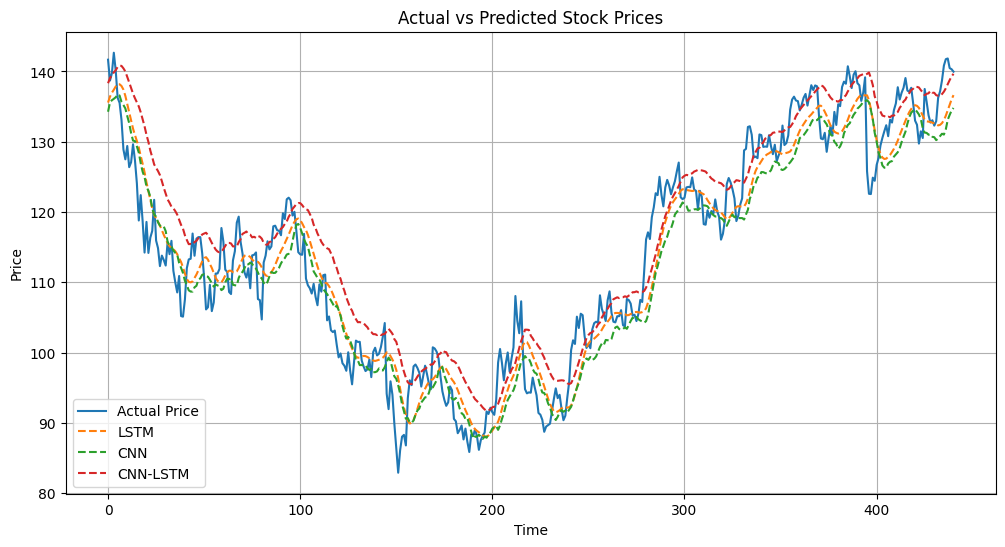


📊 MODEL PERFORMANCE COMPARISON TABLE:

      Model        MSE      RMSE  R² Score
0      LSTM  21.467613  4.633316  0.911785
1       CNN  25.408754  5.040710  0.895590
2  CNN-LSTM  36.412903  6.034310  0.850372


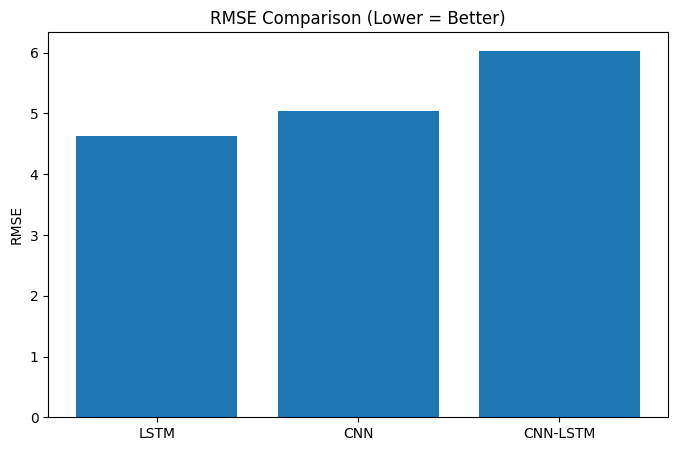

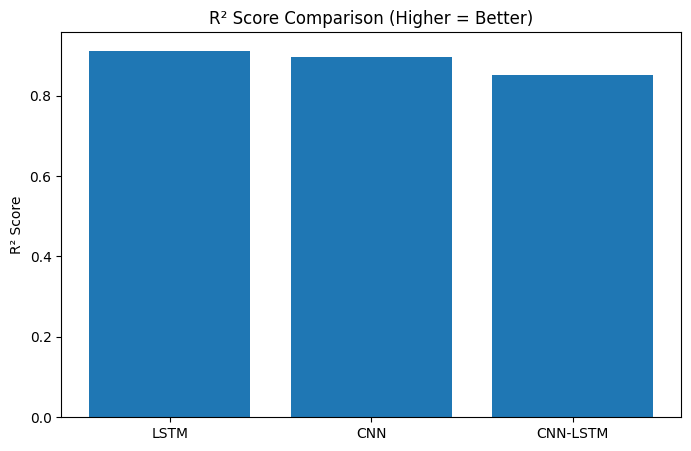

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Flatten, Dense

# ----------------- Load Data -----------------
stock = "GOOG"   # Change Stock Symbol
data = yf.download(stock, start="2015-01-01", end="2024-01-01")
data = data[['Close']]

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

X_train = X[:int(len(X)*0.8)]
y_train = y[:int(len(y)*0.8)]
X_test  = X[int(len(X)*0.8):]
y_test  = y[int(len(y)*0.8):]

# ----------------- Model 1: LSTM -----------------
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step,1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
lstm_pred = lstm_model.predict(X_test)

# ----------------- Model 2: CNN -----------------
cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step,1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_pred = cnn_model.predict(X_test)

# ----------------- Model 3: CNN-LSTM -----------------
cnn_lstm_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step,1)),
    MaxPooling1D(pool_size=2),
    LSTM(50),
    Dense(1)
])
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test)

# ----------------- Inverse Transform -----------------
actual = scaler.inverse_transform(y_test)
lstm_pred = scaler.inverse_transform(lstm_pred)
cnn_pred = scaler.inverse_transform(cnn_pred)
cnn_lstm_pred = scaler.inverse_transform(cnn_lstm_pred)

# ----------------- Plot All Models in One Figure -----------------
plt.figure(figsize=(12,6))
plt.plot(actual, label='Actual Price')
plt.plot(lstm_pred, label='LSTM', linestyle='dashed')
plt.plot(cnn_pred, label='CNN', linestyle='dashed')
plt.plot(cnn_lstm_pred, label='CNN-LSTM', linestyle='dashed')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# ----------------- Model Performance Table -----------------
def evaluate(name, true, pred):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    return [name, mse, rmse, r2]

results = [
    evaluate("LSTM", actual, lstm_pred),
    evaluate("CNN", actual, cnn_pred),
    evaluate("CNN-LSTM", actual, cnn_lstm_pred)
]

perf_table = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R² Score"])
print("\n📊 MODEL PERFORMANCE COMPARISON TABLE:\n")
print(perf_table)

# ----------------- Performance Bar Charts -----------------
plt.figure(figsize=(8,5))
plt.bar(perf_table["Model"], perf_table["RMSE"])
plt.title("RMSE Comparison (Lower = Better)")
plt.ylabel("RMSE")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(perf_table["Model"], perf_table["R² Score"])
plt.title("R² Score Comparison (Higher = Better)")
plt.ylabel("R² Score")
plt.show()